## ENTRENAMIENTO DEL MODELO DE ML PARA PREDECIR EL PRECIO DE UN CELULAR SEGUN LAS CARACTERISTICAS DE LA MISMA

Importando librerias

In [99]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [100]:
sns.set(style='whitegrid',context='notebook')

Cargamos la Data

In [101]:
df = pd.read_csv('/content/Mobiles_cleaned.csv')
df

,brand,price,is_5g,processor_brand,core,proccessor_speed,ram,internal_memory,battery_size,rear_mp,front_mp,os,display_size
0,Samsung,74999,1,Snapdragon,8,3.30,12,256,5000,200,12,Android,6.80
1,Oneplus,24997,1,Dimensity,8,3.35,8,128,7100,50,16,Android,6.77
2,Apple,47999,1,Bionic,6,3.46,6,128,3349,48,12,iOS,6.10
3,Realme,16999,1,Dimensity,8,2.40,6,128,7000,50,50,Android,6.81
4,Samsung,33890,1,Exynos,10,3.11,8,128,4700,50,10,Android,6.70
...,...,...,...,...,...,...,...,...,...,...,...,...,...
906,Iqoo,27999,1,Snapdragon,8,3.20,8,128,4700,64,16,Android,6.62
907,Xiaomi,13980,0,Helio,8,2.05,8,128,5000,64,13,Android,6.43
908,Xiaomi,16499,1,Dimensity,8,2.40,6,128,5000,50,16,Android,6.60
909,Realme,27990,1,Dimensity,8,2.50,6,128,4500,50,16,Android,6.40


## Codificacion de variables categoricas con Sklearn


# Identificamos variables categoricas

In [102]:
categorical_columns = df.select_dtypes(object).columns
categorical_columns

Index(['brand', 'processor_brand', 'os'], dtype='object')

In [103]:
df['price'] = df['price'] / 10000
df

,brand,price,is_5g,processor_brand,core,proccessor_speed,ram,internal_memory,battery_size,rear_mp,front_mp,os,display_size
0,Samsung,7.4999,1,Snapdragon,8,3.30,12,256,5000,200,12,Android,6.80
1,Oneplus,2.4997,1,Dimensity,8,3.35,8,128,7100,50,16,Android,6.77
2,Apple,4.7999,1,Bionic,6,3.46,6,128,3349,48,12,iOS,6.10
3,Realme,1.6999,1,Dimensity,8,2.40,6,128,7000,50,50,Android,6.81
4,Samsung,3.3890,1,Exynos,10,3.11,8,128,4700,50,10,Android,6.70
...,...,...,...,...,...,...,...,...,...,...,...,...,...
906,Iqoo,2.7999,1,Snapdragon,8,3.20,8,128,4700,64,16,Android,6.62
907,Xiaomi,1.3980,0,Helio,8,2.05,8,128,5000,64,13,Android,6.43
908,Xiaomi,1.6499,1,Dimensity,8,2.40,6,128,5000,50,16,Android,6.60
909,Realme,2.7990,1,Dimensity,8,2.50,6,128,4500,50,16,Android,6.40


## CODIFICACIÓN DE VARIABLES CATEGORICAS CON SKLEARN

## IDENTIFICAMOS VARIABLES CATEGORICAS

In [104]:
categorical_columns = df.select_dtypes(object).columns
categorical_columns

Index(['brand', 'processor_brand', 'os'], dtype='object')

In [105]:
for cc in categorical_columns:
  print("*"*50)
  print(df[cc].value_counts())

**************************************************
brand
Samsung     147
Realme      129
Vivo        119
Oppo         82
Xiaomi       63
Motorola     57
Poco         45
Oneplus      45
Apple        40
Iqoo         38
Infinix      30
Lava         27
Tecno        26
Google       19
Nothing      15
Alcatel       5
Hmd           5
Honor         5
Cmf           4
Ai+           4
Acer          3
Itel          3
Name: count, dtype: int64
**************************************************
processor_brand
Dimensity     393
Snapdragon    326
Exynos         58
Bionic         40
Unisoc         37
Helio          36
Tensor         19
Tiger           2
Name: count, dtype: int64
**************************************************
os
Android    871
iOS         40
Name: count, dtype: int64


In [107]:
ordinal_cols = ['os']
onehot_cols = list(set(categorical_columns) - set(ordinal_cols))
print(ordinal_cols,onehot_cols)

['os'] ['processor_brand', 'brand']


## CODIFICAMOS USANDO LOS MODULSO COMPOSE Y PREPROCESSING DE SKLEARN

In [108]:
import sklearn.compose
import sklearn.preprocessing

## CREAMOS UN TRANSFORMER

In [109]:
transformer = sklearn.compose.make_column_transformer(
    (sklearn.preprocessing.OrdinalEncoder(),ordinal_cols),
    (sklearn.preprocessing.OneHotEncoder(),onehot_cols),
    remainder='passthrough'
)
transformer

ColumnTransformer(remainder='passthrough',
                  transformers=[('ordinalencoder', OrdinalEncoder(), ['os']),
                                ('onehotencoder', OneHotEncoder(),
                                 ['processor_brand', 'brand'])])

## APLICAMOS EL TRANSFOMER A EL DATASET

In [110]:
data_transformed_df = (
    pd.DataFrame(
        transformer.fit_transform(df),
        columns = transformer.get_feature_names_out(),
        index=df.index
    )
)
data_transformed_df

,ordinalencoder__os,onehotencoder__processor_brand_Bionic,onehotencoder__processor_brand_Dimensity,onehotencoder__processor_brand_Exynos,onehotencoder__processor_brand_Helio,onehotencoder__processor_brand_Snapdragon,onehotencoder__processor_brand_Tensor,onehotencoder__processor_brand_Tiger,onehotencoder__processor_brand_Unisoc,onehotencoder__brand_Acer,...,remainder__price,remainder__is_5g,remainder__core,remainder__proccessor_speed,remainder__ram,remainder__internal_memory,remainder__battery_size,remainder__rear_mp,remainder__front_mp,remainder__display_size
0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,7.4999,1.0,8.0,3.30,12.0,256.0,5000.0,200.0,12.0,6.80
1,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,2.4997,1.0,8.0,3.35,8.0,128.0,7100.0,50.0,16.0,6.77
2,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,4.7999,1.0,6.0,3.46,6.0,128.0,3349.0,48.0,12.0,6.10
3,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.6999,1.0,8.0,2.40,6.0,128.0,7000.0,50.0,50.0,6.81
4,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,3.3890,1.0,10.0,3.11,8.0,128.0,4700.0,50.0,10.0,6.70
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
906,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,2.7999,1.0,8.0,3.20,8.0,128.0,4700.0,64.0,16.0,6.62
907,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,1.3980,0.0,8.0,2.05,8.0,128.0,5000.0,64.0,13.0,6.43
908,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.6499,1.0,8.0,2.40,6.0,128.0,5000.0,50.0,16.0,6.60
909,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,2.7990,1.0,8.0,2.50,6.0,128.0,4500.0,50.0,16.0,6.40


In [111]:
data_transformed_df = data_transformed_df.rename(
    columns=lambda x: x.replace("ordinalencoder__", "").replace("onehotencoder__", "").replace("remainder__", "")
)

data_transformed_df

,os,processor_brand_Bionic,processor_brand_Dimensity,processor_brand_Exynos,processor_brand_Helio,processor_brand_Snapdragon,processor_brand_Tensor,processor_brand_Tiger,processor_brand_Unisoc,brand_Acer,...,price,is_5g,core,proccessor_speed,ram,internal_memory,battery_size,rear_mp,front_mp,display_size
0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,7.4999,1.0,8.0,3.30,12.0,256.0,5000.0,200.0,12.0,6.80
1,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,2.4997,1.0,8.0,3.35,8.0,128.0,7100.0,50.0,16.0,6.77
2,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,4.7999,1.0,6.0,3.46,6.0,128.0,3349.0,48.0,12.0,6.10
3,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.6999,1.0,8.0,2.40,6.0,128.0,7000.0,50.0,50.0,6.81
4,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,3.3890,1.0,10.0,3.11,8.0,128.0,4700.0,50.0,10.0,6.70
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
906,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,2.7999,1.0,8.0,3.20,8.0,128.0,4700.0,64.0,16.0,6.62
907,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,1.3980,0.0,8.0,2.05,8.0,128.0,5000.0,64.0,13.0,6.43
908,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.6499,1.0,8.0,2.40,6.0,128.0,5000.0,50.0,16.0,6.60
909,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,2.7990,1.0,8.0,2.50,6.0,128.0,4500.0,50.0,16.0,6.40


In [112]:
data_transformed_df.dtypes

,0
os,float64
processor_brand_Bionic,float64
processor_brand_Dimensity,float64
processor_brand_Exynos,float64
processor_brand_Helio,float64
processor_brand_Snapdragon,float64
processor_brand_Tensor,float64
processor_brand_Tiger,float64
processor_brand_Unisoc,float64
brand_Acer,float64


In [113]:
data_transformed_df.to_csv('Mobiles_transformed.csv',index=None)

In [115]:
data_transformed_df = pd.read_csv('/content/Mobiles_transformed.csv')
data_transformed_df

,os,processor_brand_Bionic,processor_brand_Dimensity,processor_brand_Exynos,processor_brand_Helio,processor_brand_Snapdragon,processor_brand_Tensor,processor_brand_Tiger,processor_brand_Unisoc,brand_Acer,...,price,is_5g,core,proccessor_speed,ram,internal_memory,battery_size,rear_mp,front_mp,display_size
0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,7.4999,1.0,8.0,3.30,12.0,256.0,5000.0,200.0,12.0,6.80
1,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,2.4997,1.0,8.0,3.35,8.0,128.0,7100.0,50.0,16.0,6.77
2,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,4.7999,1.0,6.0,3.46,6.0,128.0,3349.0,48.0,12.0,6.10
3,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.6999,1.0,8.0,2.40,6.0,128.0,7000.0,50.0,50.0,6.81
4,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,3.3890,1.0,10.0,3.11,8.0,128.0,4700.0,50.0,10.0,6.70
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
906,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,2.7999,1.0,8.0,3.20,8.0,128.0,4700.0,64.0,16.0,6.62
907,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,1.3980,0.0,8.0,2.05,8.0,128.0,5000.0,64.0,13.0,6.43
908,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.6499,1.0,8.0,2.40,6.0,128.0,5000.0,50.0,16.0,6.60
909,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,2.7990,1.0,8.0,2.50,6.0,128.0,4500.0,50.0,16.0,6.40


## CORRELACIONES

In [117]:
corr_matrix = data_transformed_df.corr()
corr_charges = corr_matrix['price']
corr_charges.sort_values(ascending=False)

,price
price,1.000000
internal_memory,0.680224
proccessor_speed,0.659223
ram,0.538021
brand_Apple,0.520840
processor_brand_Bionic,0.520840
os,0.520840
display_size,0.237773
is_5g,0.225594
rear_mp,0.221599


<Axes: >

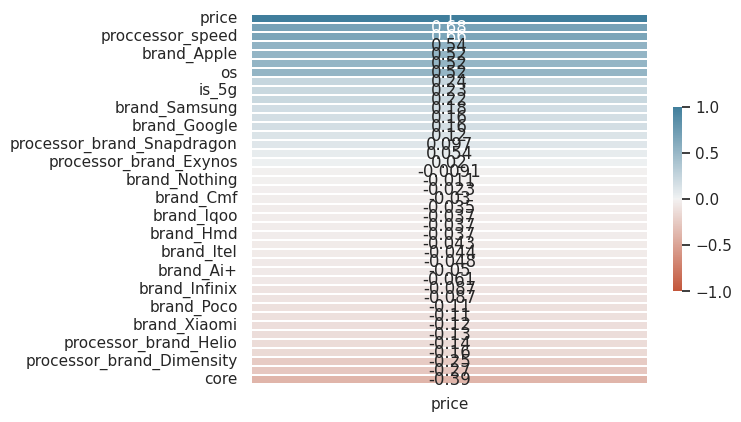

In [131]:
sns.heatmap(
    data=corr_charges.sort_values(ascending=False).to_frame(),
    cmap=sns.diverging_palette(20, 230, as_cmap=True),
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=0.3,
    cbar_kws={"shrink": 0.5},
    annot=True
)

## IDENTIFICAMOS VARIABLE X y Y , dividimos en train test

In [132]:
cols = corr_charges.index.tolist()
cols.remove('price')
cols

['os',
 'processor_brand_Bionic',
 'processor_brand_Dimensity',
 'processor_brand_Exynos',
 'processor_brand_Helio',
 'processor_brand_Snapdragon',
 'processor_brand_Tensor',
 'processor_brand_Tiger',
 'processor_brand_Unisoc',
 'brand_Acer',
 'brand_Ai+',
 'brand_Alcatel',
 'brand_Apple',
 'brand_Cmf',
 'brand_Google',
 'brand_Hmd',
 'brand_Honor',
 'brand_Infinix',
 'brand_Iqoo',
 'brand_Itel',
 'brand_Lava',
 'brand_Motorola',
 'brand_Nothing',
 'brand_Oneplus',
 'brand_Oppo',
 'brand_Poco',
 'brand_Realme',
 'brand_Samsung',
 'brand_Tecno',
 'brand_Vivo',
 'brand_Xiaomi',
 'is_5g',
 'core',
 'proccessor_speed',
 'ram',
 'internal_memory',
 'battery_size',
 'rear_mp',
 'front_mp',
 'display_size']

In [133]:
X = data_transformed_df[cols].values
y = data_transformed_df['price'].values.reshape(-1,1)

In [134]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.30,random_state=42)

## CREAMOS UN CODIGO PARA PODER EVALUAR VARIOS MODELOS

# IMPORTAMOS LIBRERIAS

In [135]:
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.preprocessing import StandardScaler,MinMaxScaler

ESCALAMIENTO DE DATOS

In [144]:
scaler_X = StandardScaler()
X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)

scaler_y = StandardScaler()
y_train_scaled = scaler_y.fit_transform(y_train)
y_test_scaled = scaler_y.transform(y_test)

# CREAMOS DICCIONARIO DE MODELOS

In [137]:
models = {
    "Linear Regression": LinearRegression(),
    "Lasso": Lasso(alpha=0.1),
    "Ridge": Ridge(alpha=1.0),
    "KNN Regressor": KNeighborsRegressor(n_neighbors=10),
    "SVR": SVR(kernel='rbf'),
    "Random Forest Regressor": RandomForestRegressor(n_estimators=100, random_state=42)
}

# CREAMOS BUCLE PARA PROBAR CADA MODELO DEL DICCIONARIO

In [138]:
results = {}
for name,model in models.items():

  model.fit(X_train_scaled,y_train_scaled.ravel())
  y_pred_scaled = model.predict(X_test_scaled)

  r2 = r2_score(y_test_scaled, y_pred_scaled)
  mse = mean_squared_error(y_test_scaled, y_pred_scaled)
  mae = mean_absolute_error(y_test_scaled, y_pred_scaled)
  results[name] = {"R2": r2, "MSE": mse, "MAE": mae}

# MOSTRAMOS RESULTADOS DE LOS MODELOS ENTRENADOS

In [139]:
results_df = pd.DataFrame(results).T
print("Model Comparison:")
display(results_df)

Model Comparison:


,R2,MSE,MAE
Linear Regression,0.800021,0.252967,0.309886
Lasso,0.658608,0.431852,0.340979
Ridge,0.799975,0.253026,0.309811
KNN Regressor,0.776102,0.283225,0.253422
SVR,0.769055,0.292139,0.219718
Random Forest Regressor,0.894835,0.133030,0.172954


# BUSCAMOS EL MEJOR MODELO

In [140]:
best_r2_model = results_df['R2'].idxmax()
best_mse_model = results_df['MSE'].idxmin()
print(f"\nBest model based on R2: {best_r2_model} (R2: {results_df.loc[best_r2_model, 'R2']:.4f})")
print(f"Best model based on MSE: {best_mse_model} (MSE: {results_df.loc[best_mse_model, 'MSE']:.2f})")


Best model based on R2: Random Forest Regressor (R2: 0.8948)
Best model based on MSE: Random Forest Regressor (MSE: 0.13)


# GRAFICAMOS RESULTADOS

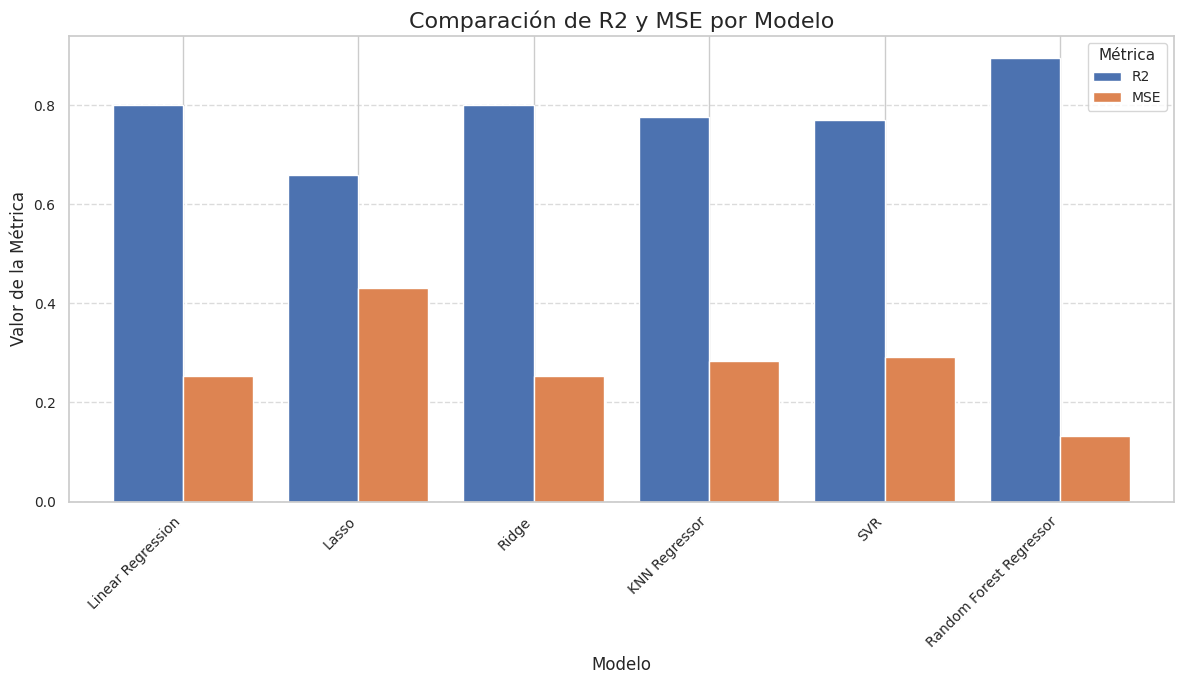

In [141]:
import matplotlib.pyplot as plt
import seaborn as sns

# Seleccionar solo las métricas R2 y MSE para comparar
results_to_plot = results_df[['R2', 'MSE']]

# Crear el gráfico de barras comparativo
fig, ax = plt.subplots(figsize=(12, 7))
results_to_plot.plot(kind='bar', ax=ax, width=0.8)

plt.title('Comparación de R2 y MSE por Modelo', fontsize=16)
plt.ylabel('Valor de la Métrica', fontsize=12)
plt.xlabel('Modelo', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='Métrica', fontsize=10, title_fontsize='11')
plt.tight_layout()
plt.show()

In [147]:
import joblib
joblib.dump(models[best_r2_model],'model.pkl')
joblib.dump(scaler_X,'scaler_X.pkl')
joblib.dump(scaler_y,'scaler_y.pkl')

['scaler_y.pkl']